In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('titanic_toy.csv')

In [8]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [14]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [17]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [19]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state=42 , test_size=0.2)

In [22]:
X_train.shape , X_test.shape

((712, 3), (179, 3))

In [24]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [27]:
mean_age = X_train['Age'].mean()
mean_fare = X_train['Fare'].mean()

median_age = X_train['Age'].median()
median_fare = X_train['Fare'].median()

In [31]:
X_train.sample(5)

,Age,Fare,Family
624,21.0,16.100,0
675,18.0,7.775,0
633,NaN,NaN,0
683,14.0,46.900,7
863,NaN,69.550,10


In [34]:
# using pandas
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

X_train['Fare_mean'] = X_train['Age'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Age'].fillna(median_fare)

In [36]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
868,NaN,9.5000,0,29.498846,28.0,32.517788,14.4
48,NaN,21.6792,2,29.498846,28.0,32.517788,14.4
890,32.0,7.7500,0,32.000000,32.0,32.000000,32.0
617,26.0,16.1000,1,26.000000,26.0,26.000000,26.0
848,28.0,33.0000,1,28.000000,28.0,28.000000,28.0


In [38]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  210.2517072477438
Age Variance after median imputation:  169.20731007048096
Age Variance after mean imputation:  168.8519336687225
Original Fare variable variance:  2761.031434948639
Fare Variance after median imputation:  204.91494514688827
Fare Variance after mean imputation:  170.29366350002152


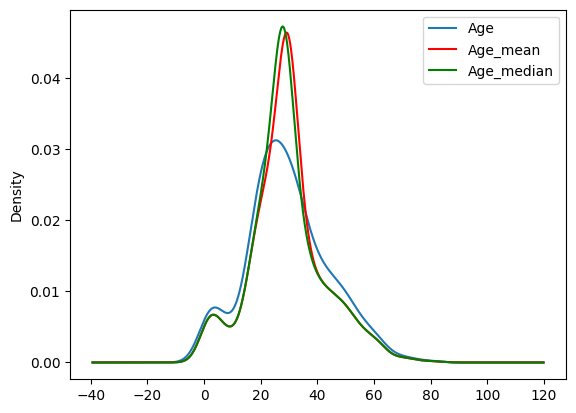

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution 
X_train['Age'].plot(kind='kde')

#varibale imputed wuth mean
X_train['Age_mean'].plot(kind='kde',color='red')

#varibale imputed wuth median
X_train['Age_median'].plot(kind='kde',color='green')

#add legend
lines , labels = ax.get_legend_handles_labels()
ax.legend(lines , labels , loc='best')

In [47]:
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,210.251707,210.251707
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,52.745200,97.632173
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,-5.673883,-5.328300
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,168.851934,168.851934
Age_median,210.251707,63.938058,-5.587710,168.851934,169.207310,168.136143,172.431870
Fare_mean,210.251707,52.745200,-5.673883,168.851934,168.136143,170.293664,161.641308
Fare_median,210.251707,97.632173,-5.328300,168.851934,172.431870,161.641308,204.914945


In [49]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,1.000000,1.000000
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,0.076859,0.129700
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,-0.258416,-0.221228
Age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.995758,0.907750
Age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.990495,0.926022
Fare_mean,1.000000,0.076859,-0.258416,0.995758,0.990495,1.000000,0.865299
Fare_median,1.000000,0.129700,-0.221228,0.907750,0.926022,0.865299,1.000000


<Axes: >

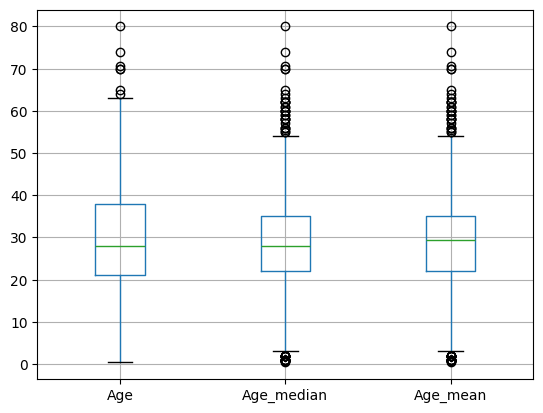

In [54]:
# box plot for the increase/decrease in no of outliers
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

## Using Sklearn

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [60]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [71]:
trf = ColumnTransformer([
    ("imputer1" , imputer1 , ['Age']),
    ("imputer2" , imputer2 , ['Fare'])
    
] , remainder='passthrough')

In [81]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [82]:
# gives median value of the col
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [84]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [85]:
X_train

,Age,Fare,Family
30,40.0,27.7208,0
10,4.0,16.7000,2
873,47.0,9.0000,0
182,9.0,31.3875,6
876,20.0,9.8458,0
...,...,...,...
534,30.0,8.6625,0
584,NaN,8.7125,0
493,71.0,49.5042,0
527,NaN,221.7792,0
